# skfuzzy

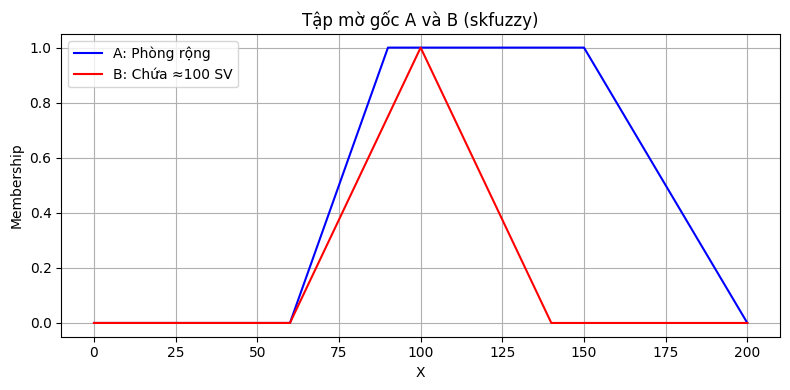

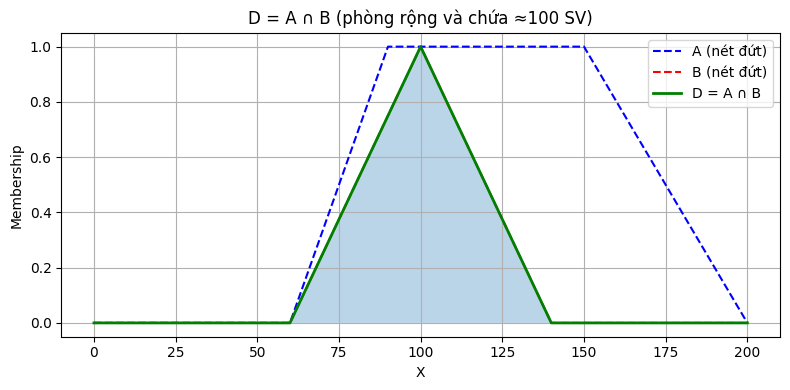

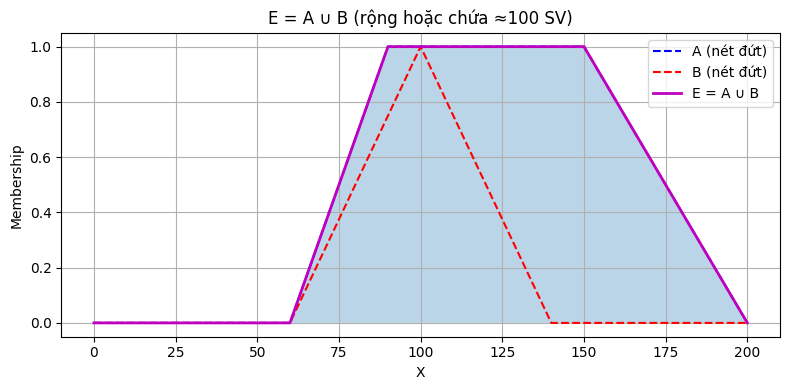

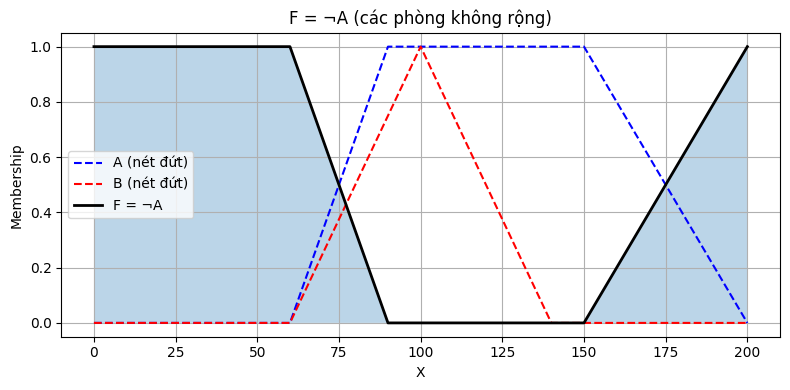

In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# ===== 1. VŨ TRỤ THẢO LUẬN (KHÔNG GIAN NỀN) =====
# Giả sử X biểu diễn diện tích/sức chứa phòng từ 0 đến 200
X = np.linspace(0, 200, 1001)   # bước 0.2 cho đường mượt

# ===== 2. ĐỊNH NGHĨA TẬP MỜ A, B BẰNG skfuzzy =====
# A: "phòng rộng" - nhỏ thì membership ≈ 0, đủ rộng (>=120) thì ≈ 1
muA = fuzz.trapmf(X, [60, 90, 150, 200])

# B: "phòng có thể chứa khoảng 100 sinh viên"
#   - tốt nhất quanh 100, giảm về 0 về hai phía
muB = fuzz.trimf(X, [60, 100, 140])

# ===== 3. XÂY DỰNG CÁC TẬP MỜ D, E, F =====
# D: các phòng học rộng mà chỉ chứa khoảng 100 SV (A ∩ B)
muD = np.fmin(muA, muB)   # min theo từng điểm

# E: các phòng học rộng hoặc có thể chứa 100 SV (A ∪ B)
muE = np.fmax(muA, muB)   # max theo từng điểm

# F: các phòng học không rộng (¬A)
muF = 1.0 - muA           # bù mờ

# ===== 4. VẼ ĐỒ THỊ MINH HỌA =====

# --- 4.1. Tập mờ gốc A, B ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b-', label='A: Phòng rộng')
plt.plot(X, muB, 'r-', label='B: Chứa ≈100 SV')
plt.title("Tập mờ gốc A và B (skfuzzy)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- 4.2. D = A ∩ B ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (nét đứt)')
plt.plot(X, muB, 'r--', label='B (nét đứt)')
plt.plot(X, muD, 'g-', linewidth=2, label='D = A ∩ B')
plt.fill_between(X, muD, 0, alpha=0.3)
plt.title("D = A ∩ B (phòng rộng và chứa ≈100 SV)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- 4.3. E = A ∪ B ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (nét đứt)')
plt.plot(X, muB, 'r--', label='B (nét đứt)')
plt.plot(X, muE, 'm-', linewidth=2, label='E = A ∪ B')
plt.fill_between(X, muE, 0, alpha=0.3)
plt.title("E = A ∪ B (rộng hoặc chứa ≈100 SV)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- 4.4. F = ¬A ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (nét đứt)')
plt.plot(X, muB, 'r--', label='B (nét đứt)')
plt.plot(X, muF, 'k-', linewidth=2, label='F = ¬A')
plt.fill_between(X, muF, 0, alpha=0.3)
plt.title("F = ¬A (các phòng không rộng)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


# Rời rạc

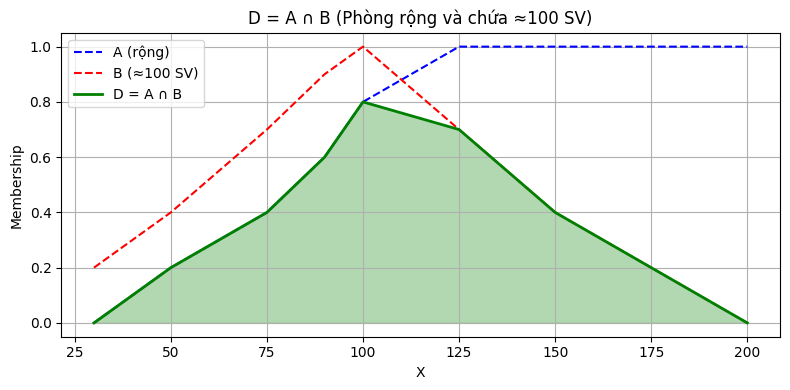

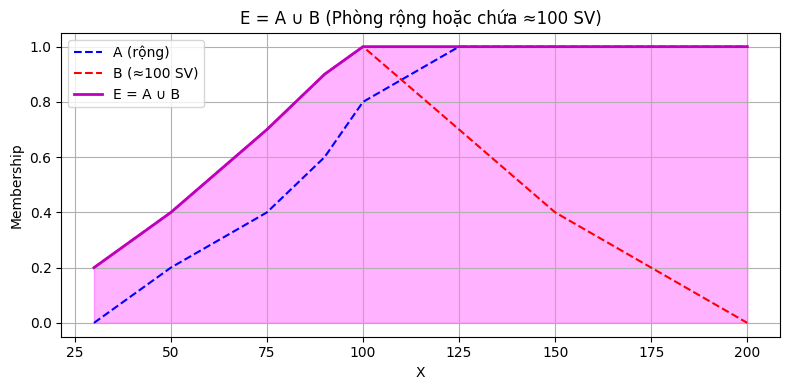

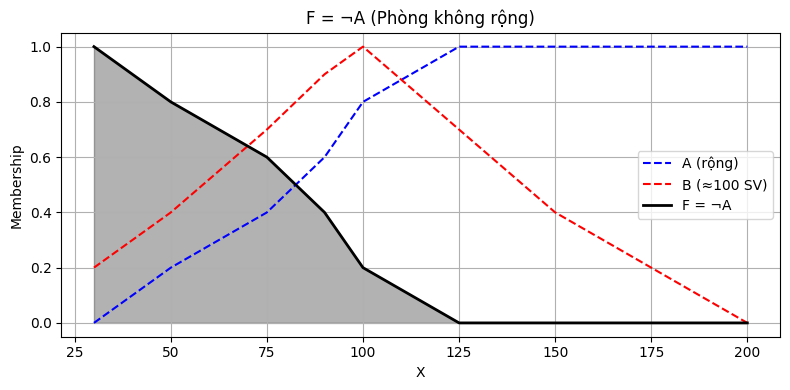

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. KHÔNG GIAN NỀN =====
X = np.array([30, 50, 75, 90, 100, 125, 150, 200], dtype=float)

# ===== 2. TẬP MỜ GỐC =====
muA = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.0, 1.0])   # A: phòng rộng
muB = np.array([0.2, 0.4, 0.7, 0.9, 1.0, 0.7, 0.4, 0.0])   # B: ≈100 SV

# ===== 3. TẬP MỜ THEO PHÉP TOÁN MỜ =====
muD = np.minimum(muA, muB)      # D = A ∩ B
muE = np.maximum(muA, muB)      # E = A ∪ B
muF = 1 - muA                   # F = ¬A

# ===== 4. VẼ TỪNG ĐỒ THỊ =====

# --- D = A ∩ B ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (rộng)')
plt.plot(X, muB, 'r--', label='B (≈100 SV)')
plt.plot(X, muD, 'g-', linewidth=2, label='D = A ∩ B')
plt.fill_between(X, muD, 0, alpha=0.3, color='green')
plt.title("D = A ∩ B (Phòng rộng và chứa ≈100 SV)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- E = A ∪ B ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (rộng)')
plt.plot(X, muB, 'r--', label='B (≈100 SV)')
plt.plot(X, muE, 'm-', linewidth=2, label='E = A ∪ B')
plt.fill_between(X, muE, 0, alpha=0.3, color='magenta')
plt.title("E = A ∪ B (Phòng rộng hoặc chứa ≈100 SV)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

# --- F = ¬A ---
plt.figure(figsize=(8,4))
plt.plot(X, muA, 'b--', label='A (rộng)')
plt.plot(X, muB, 'r--', label='B (≈100 SV)')
plt.plot(X, muF, 'k-', linewidth=2, label='F = ¬A')
plt.fill_between(X, muF, 0, alpha=0.3, color='black')
plt.title("F = ¬A (Phòng không rộng)")
plt.xlabel("X"); plt.ylabel("Membership")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()
